In [6]:
import pandas as pd
import pyodbc
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=LAPTOP-9K51NHS7\\SQLEXPRESS;"
    "DATABASE=fraud_analysis;"
    "Trusted_Connection=yes;"
)

query = "SELECT * FROM clean_fraud_data"
df = pd.read_sql(query, conn)

df.head()

,transaction_id,transaction_amount,transaction_timestamp,is_fraud,hour,is_night,user_account_age_days,kyc_verified,device_type,operating_system,country,city,payment_method,card_type,merchant_category
0,TXN00000001,7606.330078,2025-04-14 10:30:40,False,10,False,1670,1,mobile,Windows,Bangladesh,Rajshahi,nagad,debit,fashion
1,TXN00000002,3791.360107,2024-05-21 22:55:27,False,22,False,1670,1,desktop,Windows,Bangladesh,Rajshahi,card,credit,electronics
2,TXN00000003,339.549988,2025-05-26 02:58:16,False,2,True,1670,1,mobile,Windows,Bangladesh,Chittagong,bank,credit,travel
3,TXN00000004,136.490005,2024-02-15 06:00:28,False,6,False,1670,1,desktop,Android,Bangladesh,Rajshahi,bkash,debit,grocery
4,TXN00000005,1155.949951,2024-05-07 09:57:47,False,9,False,1670,1,tablet,iOS,Bangladesh,Rajshahi,bank,credit,fashion


In [3]:
df.describe()

,transaction_amount,transaction_timestamp,hour,user_account_age_days,kyc_verified
count,999999.000000,999999,999999.000000,999999.000000,999999.0
mean,2003.324635,2024-12-31 10:48:54.906602,11.504070,1005.146292,1.0
min,0.010000,2024-01-01 00:00:04,0.000000,10.000000,1.0
25%,578.359985,2024-07-01 18:06:18.500000,6.000000,507.000000,1.0
50%,1388.160034,2024-12-31 00:07:17,12.000000,1006.000000,1.0
75%,2775.944946,2025-07-02 03:20:42.500000,18.000000,1508.000000,1.0
max,31083.800781,2026-01-01 23:59:53,23.000000,2000.000000,1.0
std,2002.068307,NaN,6.924325,575.471674,0.0


In [5]:
df.groupby('device_type')['is_fraud'].mean()

device_type
desktop    0.091681
mobile     0.091516
tablet     0.091934
Name: is_fraud, dtype: float64

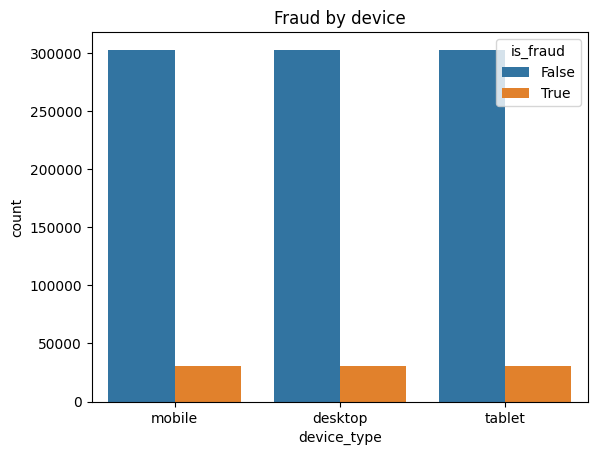

In [7]:
# Fraud by device

sns.countplot(x = "device_type", hue = "is_fraud", data = df)
plt.title("Fraud by device")
plt.show()

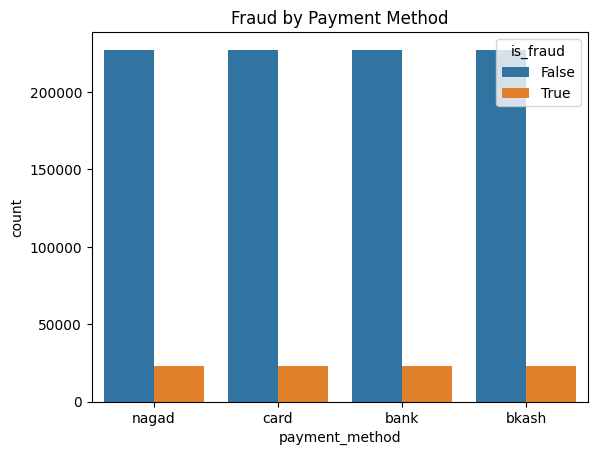

In [8]:
# Fraud by Payment
sns.countplot(x='payment_method', hue='is_fraud', data=df)
plt.title("Fraud by Payment Method")
plt.show()